In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("monthly-car-sales.csv")

In [19]:
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   108 non-null    object
 1   Sales   108 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [21]:
df.describe()

,Sales
count,108.000000
mean,14595.111111
std,4525.213913
min,5568.000000
25%,11391.250000
50%,14076.000000
75%,17595.750000
max,26099.000000


In [22]:
df["Month"] = pd.to_datetime(df["Month"])
df.head()

,Month,Sales
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


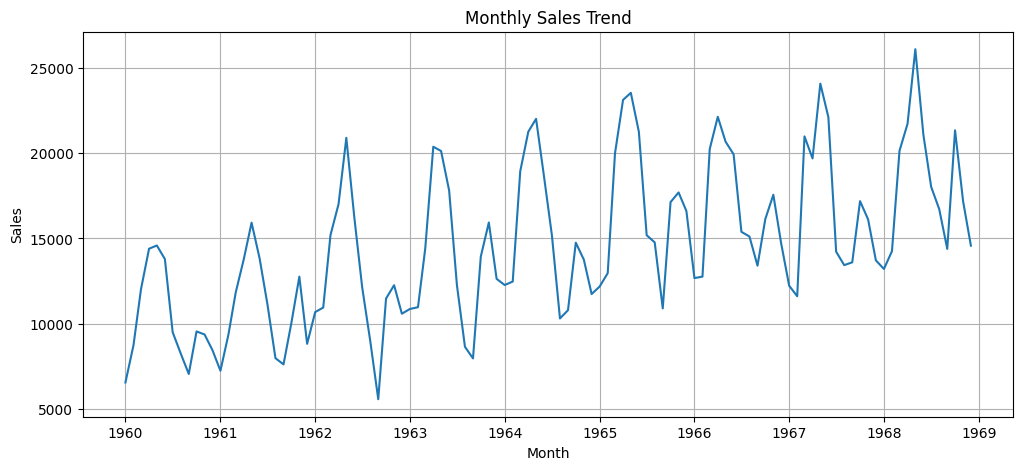

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Month"], df["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [24]:
df["Year"] = df["Month"].dt.year
df["Month_Number"] = df["Month"].dt.month

df.head()

,Month,Sales,Year,Month_Number
0,1960-01-01,6550,1960,1
1,1960-02-01,8728,1960,2
2,1960-03-01,12026,1960,3
3,1960-04-01,14395,1960,4
4,1960-05-01,14587,1960,5


In [25]:
from sklearn.model_selection import train_test_split

X = df[["Year", "Month_Number"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 86
Testing Data: 22


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [27]:
predictions = model.predict(X_test)

print(predictions[:10])

[16744.39302391 10072.8022754  11182.4456153  15634.749684
 16341.40003298 15416.69724973 12728.19382375 13131.18681468
 16592.56434488  9887.86171875]


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))

MAE : 2238.88
RMSE : 2754.68


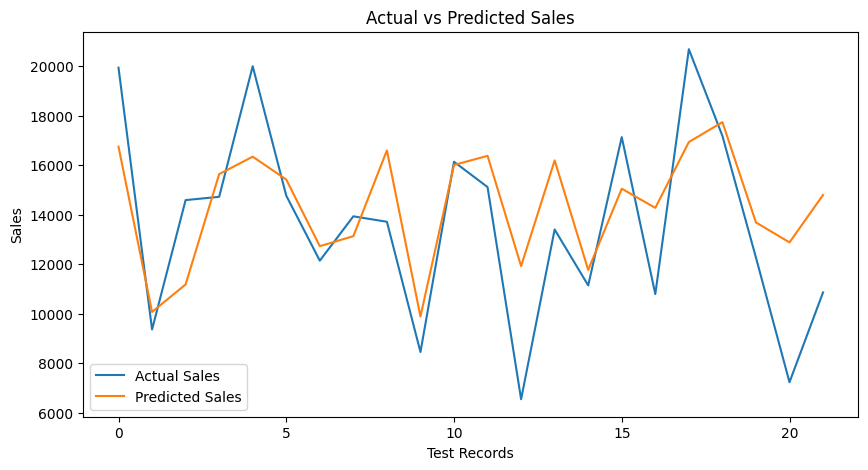

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Records")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [30]:
future_data = pd.DataFrame({
    "Year": [1969, 1969, 1969],
    "Month_Number": [1, 2, 3]
})

future_prediction = model.predict(future_data)

print("Future Sales Prediction")
print(future_prediction)

Future Sales Prediction
[20542.53978978 20357.59923313 20172.65867648]


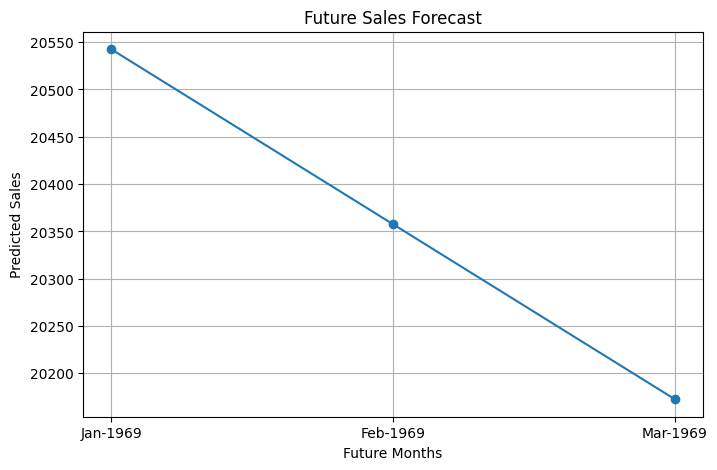

In [31]:
plt.figure(figsize=(8,5))

months = ["Jan-1969", "Feb-1969", "Mar-1969"]

plt.plot(months, future_prediction, marker="o")

plt.title("Future Sales Forecast")

plt.xlabel("Future Months")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()